In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
from sklearn.datasets import load_iris   # data_sets → datasets
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values  # "petal len" → tam isim
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

Perceptron(random_state=42)

Accuracy: 1.0


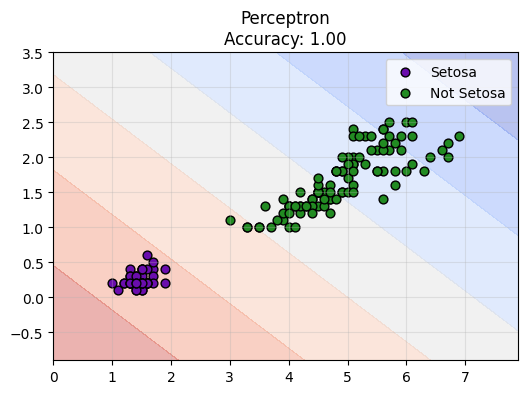

In [8]:
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

y_pred = per_clf.predict(X)
print("Accuracy:", accuracy_score(y, y_pred))

fig, ax = plt.subplots(figsize=(6, 4))
DecisionBoundaryDisplay.from_estimator(per_clf, X, alpha=0.4, ax=ax, cmap="coolwarm")
ax.scatter(X[:, 0][y==1], X[:, 1][y==1], color="#6A0DAD", s=40, edgecolors="k", label="Setosa")
ax.scatter(X[:, 0][y==0], X[:, 1][y==0], color="#228B22", s=40, edgecolors="k", label="Not Setosa")
ax.set_title(f"Perceptron\nAccuracy: {accuracy_score(y, per_clf.predict(X)):.2f}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

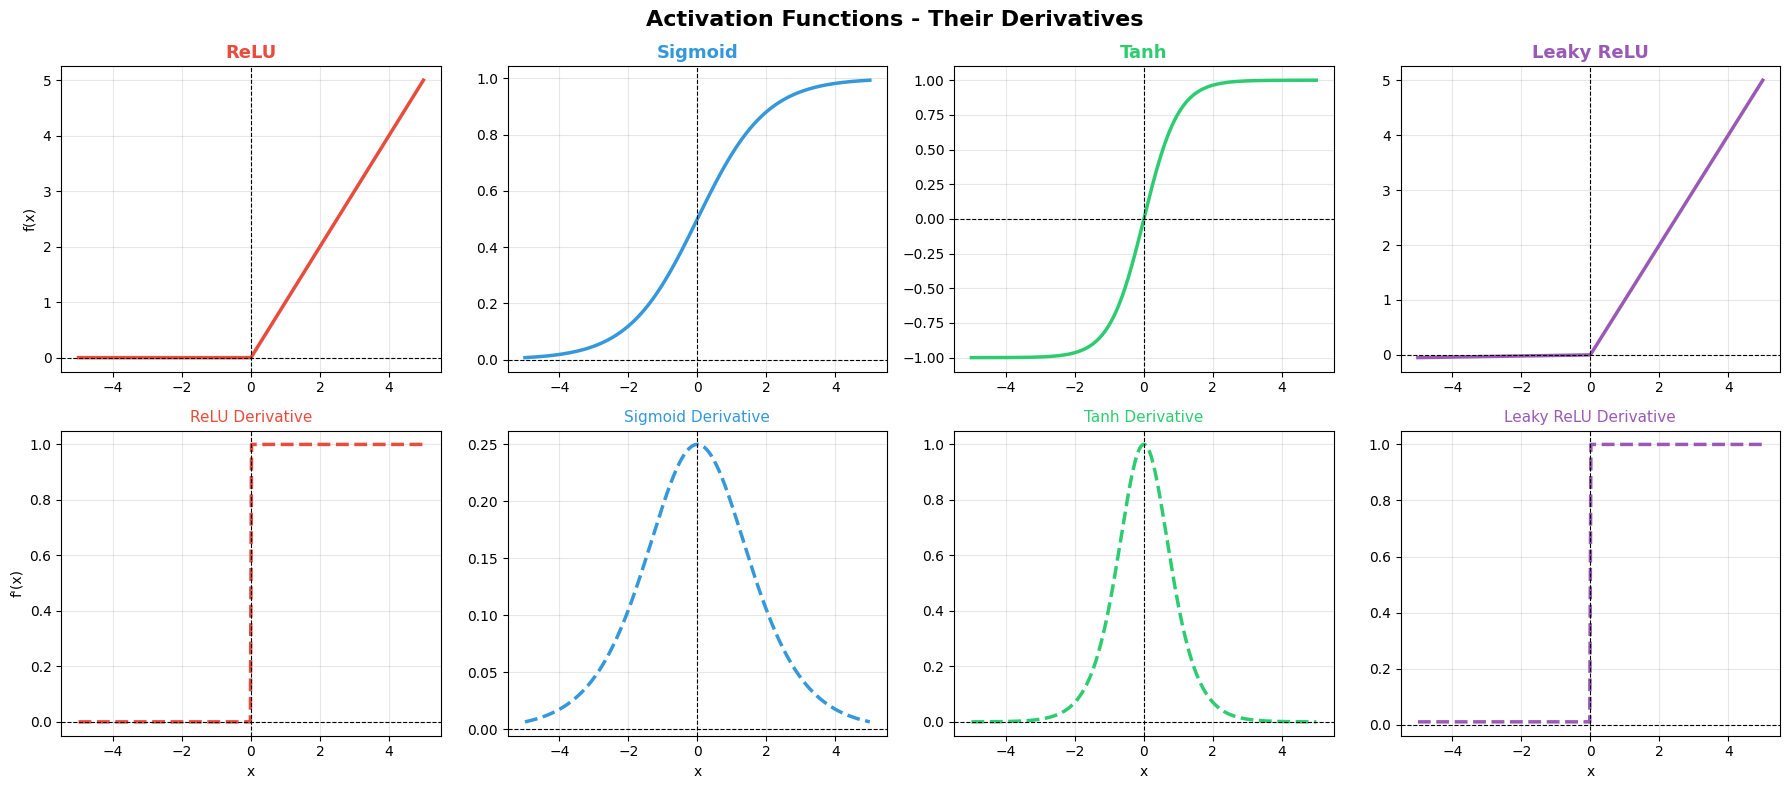

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 300)

def relu(x):
    return np.maximum(0, x)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def tanh(x):
    return np.tanh(x)
def leaky_relu(x):
    return np.where(x > 0, x, 0.01 * x)


def relu_deriv(x):
    return np.where(x > 0, 1, 0)
def sigmoid_deriv(x):
    return sigmoid(x) * (1 - sigmoid(x))
def tanh_deriv(x):
    return 1 - np.tanh(x) ** 2
def leaky_relu_deriv(x):
    return np.where(x > 0, 1, 0.01)

functions = [
    (relu,       relu_deriv,       "ReLU",        "#E74C3C"),
    (sigmoid,    sigmoid_deriv,    "Sigmoid",      "#3498DB"),
    (tanh,       tanh_deriv,       "Tanh",         "#2ECC71"),
    (leaky_relu, leaky_relu_deriv, "Leaky ReLU",   "#9B59B6"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Activation Functions - Their Derivatives", fontsize=16, fontweight="bold")

for i, (fn, deriv, name, color) in enumerate(functions):
    axes[0, i].plot(x, fn(x), color=color, linewidth=2.5)
    axes[0, i].axhline(0, color="k", linewidth=0.8, linestyle="--")
    axes[0, i].axvline(0, color="k", linewidth=0.8, linestyle="--")
    axes[0, i].set_title(f"{name}", fontsize=13, fontweight="bold", color=color)
    axes[0, i].set_ylabel("f(x)" if i == 0 else "")
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].plot(x, deriv(x), color=color, linewidth=2.5, linestyle="--")
    axes[1, i].axhline(0, color="k", linewidth=0.8, linestyle="--")
    axes[1, i].axvline(0, color="k", linewidth=0.8, linestyle="--")
    axes[1, i].set_title(f"{name} Derivative", fontsize=11, color=color)
    axes[1, i].set_ylabel("f'(x)" if i == 0 else "")
    axes[1, i].set_xlabel("x")
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()